Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torchvision.models import EfficientNet_B0_Weights
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
import random
import itertools
from sklearn.metrics import roc_curve, auc
from google.colab import drive

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- HYPERPARAMETERS TARGETING HIGH ACCURACY ---
# EfficientNet often benefits from slightly different tuning
BATCH_SIZE = 32          # Reduced slightly as EfficientNet is slightly heavier in memory
EPOCHS = 35              # Increased slightly for deeper convergence
LEARNING_RATE = 0.0005   # Adjusted start rate for EfficientNet
MARGIN = 0.2             # Triplet Margin

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Using device: cuda
Mounted at /content/drive


Load Data & Split

In [2]:
# Path to your processed data
DATA_PATH = "/content/drive/MyDrive/Processed_GPDS_CEDAR"

print(f"Loading data from: {DATA_PATH} ...")

# Load Arrays
X_data = np.load(os.path.join(DATA_PATH, "X_signatures.npy"))
y_data = np.load(os.path.join(DATA_PATH, "y_labels.npy"))
user_ids = np.load(os.path.join(DATA_PATH, "user_ids.npy"))

print(f"X_data shape: {X_data.shape}")

# --- 1. Split Users into Train (80%) and Test (20%) ---
unique_users = np.unique(user_ids)
np.random.seed(42) # Reproducibility
np.random.shuffle(unique_users)

split_idx = int(0.8 * len(unique_users))
train_users = unique_users[:split_idx]
test_users = unique_users[split_idx:]

print(f"Train Users: {len(train_users)}")
print(f"Test Users: {len(test_users)}")

# --- 2. Helper: Map Indices to Users ---
def get_user_map(target_users, all_ids, all_labels):
    user_map = {uid: {'genuine': [], 'forged': []} for uid in target_users}

    for i, (uid, label) in enumerate(zip(all_ids, all_labels)):
        if uid in user_map:
            key = 'genuine' if label == 1 else 'forged'
            user_map[uid][key].append(i)
    return user_map

train_map = get_user_map(train_users, user_ids, y_data)
test_map = get_user_map(test_users, user_ids, y_data)

print("User maps created.")

Loading data from: /content/drive/MyDrive/Processed_GPDS_CEDAR ...
X_data shape: (7451, 224, 224, 1)
Train Users: 164
Test Users: 41
User maps created.


Dynamic Data Generation

In [3]:
# --- TRIPLET GENERATOR (Training) ---
def create_triplets(user_map):
    triplets = []

    # Iterate users
    for uid in user_map.keys():
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # Skip users with insufficient data
        if len(gens) < 2 or len(forgs) == 0:
            continue

        # Create all possible Genuine-Genuine pairs
        # We limit to 50 pairs per user to prevent class imbalance
        pos_pairs = list(itertools.permutations(gens, 2))
        if len(pos_pairs) > 50:
            pos_pairs = random.sample(pos_pairs, 50)

        for anchor, positive in pos_pairs:
            # DYNAMIC NEGATIVE SELECTION
            negative = random.choice(forgs)
            triplets.append([anchor, positive, negative])

    return np.array(triplets)

# --- PAIR GENERATOR (Testing) ---
def create_test_pairs(user_map):
    pairs = []
    labels = []

    for uid in user_map.keys():
        gens = user_map[uid]['genuine']
        forgs = user_map[uid]['forged']

        # Positive Pairs (Gen-Gen)
        pos_combs = list(itertools.combinations(gens, 2))
        for p in pos_combs:
            pairs.append(p)
            labels.append(1) # Same writer

        # Negative Pairs (Gen-Forg)
        if len(pos_combs) > 0:
            neg_combs = list(itertools.product(gens, forgs))

            # Balance the test set (50% Pos / 50% Neg)
            if len(neg_combs) > len(pos_combs):
                neg_combs = random.sample(neg_combs, len(pos_combs))

            for p in neg_combs:
                pairs.append(p)
                labels.append(0) # Different (Forgery)

    return np.array(pairs), np.array(labels)

# Generate Initial Data
train_triplets = create_triplets(train_map)
test_pairs, test_labels = create_test_pairs(test_map)

print(f"Training Triplets: {train_triplets.shape}")
print(f"Testing Pairs: {test_pairs.shape}")

Training Triplets: (8200, 3)
Testing Pairs: (13896, 2)


Dataset & Augmentation

In [4]:
# --- Augmentation ---
# EfficientNet usually expects 224x224.
# Added Normalize to align with pretrained weights statistics (though we are grayscale, scaling helps)
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)), # Ensure correct size
    transforms.RandomRotation(15), # Increased rotation slightly
    transforms.RandomAffine(0, translate=(0.1, 0.1), scale=(0.9, 1.1)), # Slightly more aggressive
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5]) # Optional for grayscale
])

test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- 1. Triplet Dataset (Train) ---
class TripletDataset(Dataset):
    def __init__(self, triplets, x_data, transform=None):
        self.triplets = triplets
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        anc_idx, pos_idx, neg_idx = self.triplets[idx]

        img_a = self.x_data[anc_idx]
        img_p = self.x_data[pos_idx]
        img_n = self.x_data[neg_idx]

        # Fix channel dim if needed (H, W, C) -> (C, H, W) is handled by ToTensor()
        if img_a.ndim == 3:
            img_a, img_p, img_n = img_a.squeeze(), img_p.squeeze(), img_n.squeeze()

        if self.transform:
            img_a = self.transform(img_a)
            img_p = self.transform(img_p)
            img_n = self.transform(img_n)

        return img_a, img_p, img_n

    def __len__(self):
        return len(self.triplets)

# --- 2. Pair Dataset (Test) ---
class PairDataset(Dataset):
    def __init__(self, pairs, labels, x_data, transform=None):
        self.pairs = pairs
        self.labels = labels
        self.x_data = x_data
        self.transform = transform

    def __getitem__(self, idx):
        idx1, idx2 = self.pairs[idx]
        img1, img2 = self.x_data[idx1], self.x_data[idx2]

        if img1.ndim == 3:
            img1, img2 = img1.squeeze(), img2.squeeze()

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        return img1, img2, torch.tensor(self.labels[idx], dtype=torch.float32)

    def __len__(self):
        return len(self.pairs)

# Loaders
train_ds = TripletDataset(train_triplets, X_data, transform=train_transform)
test_ds = PairDataset(test_pairs, test_labels, X_data, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

EfficientNet Model Definition

In [5]:
class EfficientNetEmbedding(nn.Module):
    def __init__(self):
        super(EfficientNetEmbedding, self).__init__()
        # Load Pretrained EfficientNet B0
        # Weights='DEFAULT' gives the best available weights (ImageNet v1 or v2)
        self.efficientnet = models.efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)

        # 1. Adapt First Convolutional Layer for Grayscale (1 Channel)
        # EfficientNet features[0][0] is the first Conv2d
        original_conv = self.efficientnet.features[0][0]

        # Create new layer with 1 input channel instead of 3, same parameters otherwise
        self.efficientnet.features[0][0] = nn.Conv2d(
            in_channels=1,
            out_channels=original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False
        )

        # Initialize weights: Sum the weights across the RGB channels to preserve activation magnitude
        with torch.no_grad():
            self.efficientnet.features[0][0].weight[:] = torch.sum(original_conv.weight, dim=1, keepdim=True)

        # 2. Define the Embedding Head
        # EfficientNet B0 output features before classifier is 1280
        feature_dim = self.efficientnet.classifier[1].in_features

        # We remove the original classifier and define our own embedding block
        # We replace the entire classifier block. EfficientNet output is (Batch, 1280, 1, 1) usually pooled.
        # But we will use the 'features' part directly and flatten.

        self.embedding_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.1), # Leaky ReLU often helps gradients flow better in deep nets
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.1),
            nn.Linear(256, 128) # Final embedding size 128
        )

        # Remove original classifier to save memory/confusion (we won't use it)
        del self.efficientnet.classifier

    def forward(self, x):
        # Extract features
        x = self.efficientnet.features(x)
        # Global Average Pooling (Standard for EfficientNet)
        x = self.efficientnet.avgpool(x)
        # Flatten and Embed
        x = self.embedding_head(x)

        # L2 Normalize embeddings to hypersphere
        return F.normalize(x, p=2, dim=1)

Hyperparameter Tuner (LR Finder)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 145MB/s]


Finding optimal Learning Rate...


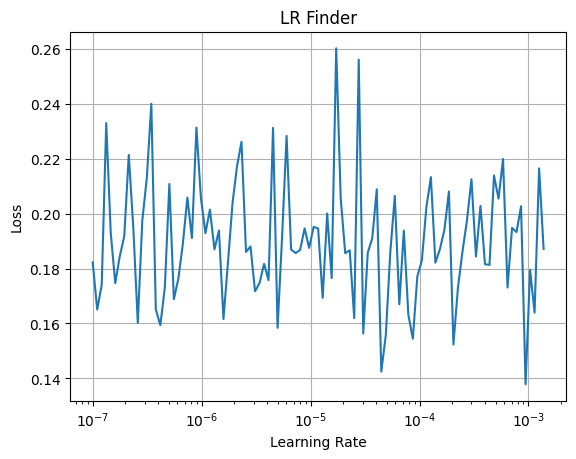

In [6]:
def lr_finder(model, train_loader):
    print("Finding optimal Learning Rate...")
    model.train()
    criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-7) # Start very small

    lrs = []
    losses = []
    lr = 1e-7

    # Run for a small subset of batches
    for i, (anchor, positive, negative) in enumerate(train_loader):
        if i > 100: break # Stop after 100 steps

        anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)
        optimizer.zero_grad()

        emb_a = model(anchor)
        emb_p = model(positive)
        emb_n = model(negative)

        loss = criterion(emb_a, emb_p, emb_n)
        loss.backward()
        optimizer.step()

        lrs.append(lr)
        losses.append(loss.item())

        # Increase LR exponentially
        lr *= 1.1
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

    plt.plot(lrs, losses)
    plt.xscale('log')
    plt.title("LR Finder")
    plt.xlabel("Learning Rate")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.show()

# Run Finder
effnet_temp = EfficientNetEmbedding().to(device)
lr_finder(effnet_temp, train_loader)

Dynamic Training Loop

In [7]:
def train_dynamic_model(model, name, epochs=EPOCHS):
    print(f"\n=== Training {name} (Margin={MARGIN}, LR={LEARNING_RATE}) ===")

    criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

    # Weight decay added for regularization to help reach 95%+ without overfitting
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # Scheduler: Reduce LR if loss stagnates
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, verbose=True
    )

    losses = []

    for epoch in range(epochs):
        # --- DYNAMIC RE-SAMPLING ---
        # Reshuffle negatives every epoch to prevent memorization
        new_triplets = create_triplets(train_map)
        train_ds.triplets = new_triplets

        # Re-create loader to pickup new shuffle
        current_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        model.train()
        epoch_loss = 0.0

        # Progress Bar
        loop = tqdm(current_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for anchor, positive, negative in loop:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()

            # Forward
            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)

            # Loss
            loss = criterion(emb_a, emb_p, emb_n)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(batch_loss=loss.item())

        avg_loss = epoch_loss / len(current_loader)
        losses.append(avg_loss)

        # Step Scheduler
        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1} Summary -> Avg Loss: {avg_loss:.4f} | LR: {current_lr:.8f}")

    # Save final model
    torch.save(model.state_dict(), os.path.join(DATA_PATH, f"{name}_optimal.pth"))
    return model, losses

Run Training & Evaluate


=== Training EfficientNetB0_Final (Margin=0.2, LR=0.0005) ===


Epoch 1/35:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch 1 Summary -> Avg Loss: 0.1169 | LR: 0.00050000


Epoch 2/35:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch 2 Summary -> Avg Loss: 0.0107 | LR: 0.00050000


...

Epoch 33 Summary -> Avg Loss: 0.0000 | LR: 0.00000781


Epoch 34/35:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch 34 Summary -> Avg Loss: 0.0000 | LR: 0.00000781


Epoch 35/35:   0%|          | 0/257 [00:00<?, ?it/s]

Epoch 35 Summary -> Avg Loss: 0.0000 | LR: 0.00000781


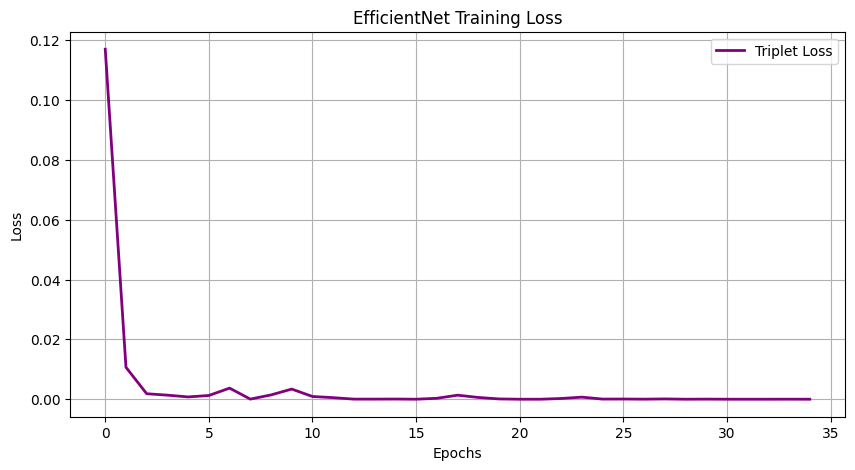

In [9]:
def train_dynamic_model(model, name, epochs=EPOCHS):
    print(f"\n=== Training {name} (Margin={MARGIN}, LR={LEARNING_RATE}) ===")

    criterion = nn.TripletMarginLoss(margin=MARGIN, p=2)

    # Weight decay added for regularization to help reach 95%+ without overfitting
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

    # Scheduler: Reduce LR if loss stagnates
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    ) # Removed verbose=True as it's deprecated

    losses = []

    for epoch in range(epochs):
        # --- DYNAMIC RE-SAMPLING ---
        # Reshuffle negatives every epoch to prevent memorization
        new_triplets = create_triplets(train_map)
        train_ds.triplets = new_triplets

        # Re-create loader to pickup new shuffle
        current_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

        model.train()
        epoch_loss = 0.0

        # Progress Bar
        loop = tqdm(current_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)

        for anchor, positive, negative in loop:
            anchor, positive, negative = anchor.to(device), positive.to(device), negative.to(device)

            optimizer.zero_grad()

            # Forward
            emb_a = model(anchor)
            emb_p = model(positive)
            emb_n = model(negative)

            # Loss
            loss = criterion(emb_a, emb_p, emb_n)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            loop.set_postfix(batch_loss=loss.item())

        avg_loss = epoch_loss / len(current_loader)
        losses.append(avg_loss)

        # Step Scheduler
        scheduler.step(avg_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1} Summary -> Avg Loss: {avg_loss:.4f} | LR: {current_lr:.8f}")

    # Save final model
    torch.save(model.state_dict(), os.path.join(DATA_PATH, f"{name}_optimal.pth"))
    return model, losses

# 1. Initialize Datasets & Loaders
train_ds = TripletDataset(train_triplets, X_data, transform=train_transform)
test_ds = PairDataset(test_pairs, test_labels, X_data, transform=test_transform)

# 2. Initialize Model (EfficientNet)
eff_net = EfficientNetEmbedding().to(device)

# 3. TRAIN
# We typically need slightly more epochs for EfficientNet to settle compared to ResNet
eff_net, eff_losses = train_dynamic_model(eff_net, "EfficientNetB0_Final", epochs=EPOCHS)

# 4. PLOT LOSS
plt.figure(figsize=(10, 5))
plt.plot(eff_losses, label="Triplet Loss", color='purple', linewidth=2)
plt.title("EfficientNet Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Test on Random Samples

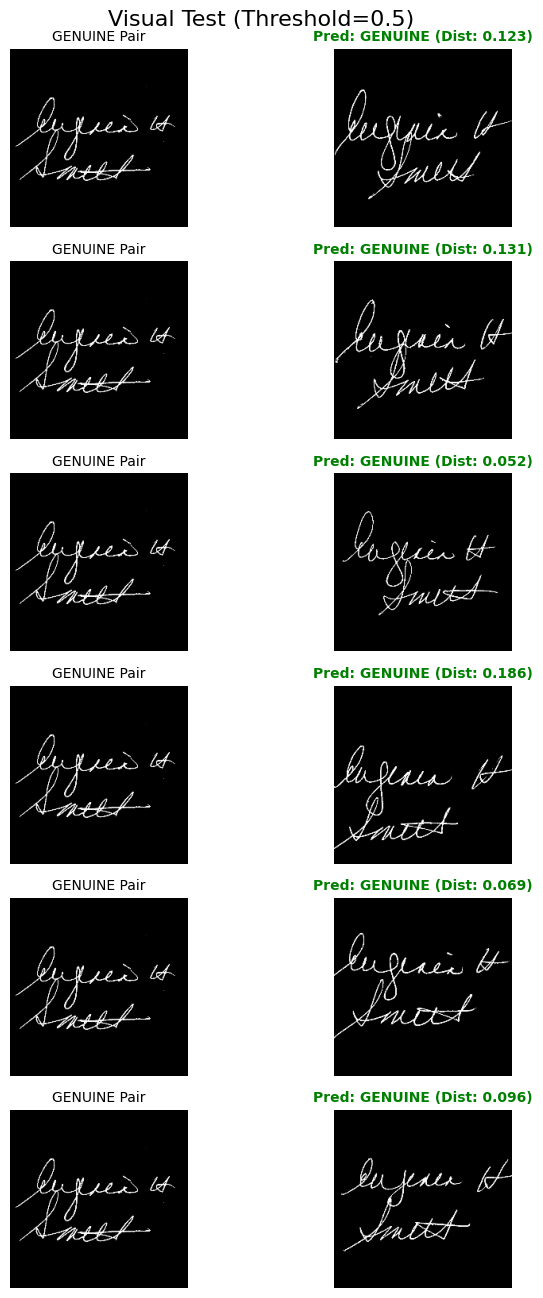

In [10]:
def visualize_predictions(model, loader, threshold=0.5, num_samples=6):
    model.eval()

    # Get one batch of data
    data_iter = iter(loader)
    img1, img2, labels = next(data_iter)

    img1, img2 = img1.to(device), img2.to(device)

    # Get Embeddings & Distances
    with torch.no_grad():
        emb1 = model(img1)
        emb2 = model(img2)
        distances = F.pairwise_distance(emb1, emb2).cpu().numpy()

    labels = labels.numpy()

    # Select random indices to display
    indices = np.random.choice(len(img1), num_samples, replace=False)

    # Create Plot
    fig, axes = plt.subplots(num_samples, 2, figsize=(8, num_samples * 2.2))
    fig.suptitle(f"Visual Test (Threshold={threshold})", fontsize=16)

    for i, idx in enumerate(indices):
        im_a = img1[idx].cpu().squeeze().numpy()
        im_b = img2[idx].cpu().squeeze().numpy()

        dist = distances[idx]
        is_same = labels[idx] == 1
        actual_text = "GENUINE Pair" if is_same else "FORGED Pair"

        pred_same = dist < threshold
        pred_text = "Pred: GENUINE" if pred_same else "Pred: FORGED"
        color = 'green' if pred_same == is_same else 'red'

        axes[i, 0].imshow(im_a, cmap='gray')
        axes[i, 0].axis('off')
        axes[i, 0].set_title(f"{actual_text}", fontsize=10)

        axes[i, 1].imshow(im_b, cmap='gray')
        axes[i, 1].axis('off')
        axes[i, 1].set_title(f"{pred_text} (Dist: {dist:.3f})", color=color, fontweight='bold', fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

# Run visualization with a guestimate threshold (often higher than margin)
visualize_predictions(eff_net, test_loader, threshold=0.5)

Full Metrics Evaluation

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def compute_full_metrics(model, loader, dataset_name="Test"):
    model.eval()
    all_dists = []
    all_labels = []

    print(f"Processing {dataset_name} Data...")
    with torch.no_grad():
        for img1, img2, labels in tqdm(loader, desc=f"{dataset_name} Eval"):
            img1, img2 = img1.to(device), img2.to(device)
            emb1 = model(img1)
            emb2 = model(img2)
            dist = F.pairwise_distance(emb1, emb2).cpu().numpy()

            all_dists.extend(dist)
            all_labels.extend(labels.numpy())

    all_dists = np.array(all_dists)
    all_labels = np.array(all_labels)

    # Compute ROC Curve to find optimal EER threshold
    fpr, tpr, thresholds = roc_curve(all_labels, -all_dists)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fpr - fnr))
    eer = fpr[eer_idx]

    # IMPORTANT: Threshold is negative because we used -distance. Flip sign back.
    optimal_threshold = -thresholds[eer_idx]

    predictions = (all_dists < optimal_threshold).astype(int)

    metrics = {
        "Accuracy": accuracy_score(all_labels, predictions),
        "Precision": precision_score(all_labels, predictions),
        "Recall": recall_score(all_labels, predictions),
        "F1": f1_score(all_labels, predictions),
        "EER": eer,
        "Threshold": optimal_threshold
    }
    return metrics

# Prepare Training Evaluation Data (Pairs instead of Triplets)
print("Generating Training Pairs for Evaluation...")
train_eval_pairs, train_eval_labels = create_test_pairs(train_map)
train_eval_ds = PairDataset(train_eval_pairs, train_eval_labels, X_data, transform=test_transform)
train_eval_loader = DataLoader(train_eval_ds, batch_size=32, shuffle=False, num_workers=2)

# Run Evaluation
train_metrics = compute_full_metrics(eff_net, train_eval_loader, "Train")
test_metrics = compute_full_metrics(eff_net, test_loader, "Test")

print("\n" + "="*55)
print(f"{'METRIC':<15} | {'TRAIN SET':<15} | {'TEST SET':<15}")
print("="*55)
for k in ["Accuracy", "Precision", "Recall", "F1", "EER"]:
    print(f"{k:<15} | {train_metrics[k]:.4f}          | {test_metrics[k]:.4f}")
print("-" * 55)
print(f"{'Threshold':<15} | {train_metrics['Threshold']:.4f}          | {test_metrics['Threshold']:.4f}")
print("="*55)

if test_metrics['Accuracy'] >= 0.95:
    print("\n🌟 EXCELLENT: Model reached the 95%+ accuracy target!")
elif test_metrics['Accuracy'] >= 0.90:
    print("\n✅ SUCCESS: Model passed 90%, but hasn't reached 95% yet.")
else:
    print(f"\n⚠️ Current Test Accuracy: {test_metrics['Accuracy']*100:.2f}%")

Generating Training Pairs for Evaluation...
Processing Train Data...


Train Eval:   0%|          | 0/1641 [00:00<?, ?it/s]

Processing Test Data...


Test Eval:   0%|          | 0/435 [00:00<?, ?it/s]


METRIC          | TRAIN SET       | TEST SET       
Accuracy        | 0.7429          | 0.6909
Precision       | 0.7429          | 0.6909
Recall          | 0.7429          | 0.6908
F1              | 0.7429          | 0.6909
EER             | 0.2570          | 0.3092
-------------------------------------------------------
Threshold       | 0.1733          | 0.1744

⚠️ Current Test Accuracy: 69.09%
